# LeetCode #6: ZigZag Conversion

https://leetcode.com/problems/zigzag-conversion/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (Matrix Simulation)** | $O(N \cdot R)$ | $O(N \cdot R)$ |
| **Row-by-Row Simulation** ★ | $O(N)$ | $O(N)$ |

---

## Understanding the Methods

### Brute Force (Matrix Simulation)
Place each character in a 2D grid at its visual zigzag position. Most cells are empty (especially with high row counts), wasting $O(N \cdot R)$ memory and requiring two full passes to populate and then read the grid.

### Optimal: Row-by-Row Simulation ★
Track only which **row** each character belongs to using a direction flag that bounces between 0 and numRows-1. Each character is appended to its row's bucket in one pass, then all buckets are concatenated.

**Why this is better than Matrix Simulation:** Same $O(N)$ traversal but $O(N)$ space vs $O(N \cdot R)$. With 1000 rows and a 14-char string, the matrix wastes 14,000 cells; the row simulation only uses space for the 14 actual characters.

**Constraints:**
* `1 <= s.length <= 1000`
* `numRows` will be in the range `[1, 1000]`

## Solutions

### C#

In [ ]:
public class Solution {
    public string Convert(string s, int numRows) {
        // Guard: no zigzag possible with one row or string shorter than row count
        if (numRows == 1 || s.Length <= numRows) return s;

        var rows = new System.Text.StringBuilder[numRows];
        for (int i = 0; i < numRows; i++) rows[i] = new System.Text.StringBuilder();

        int currRow = 0;
        bool goingDown = false;

        foreach (char c in s) {
            rows[currRow].Append(c);
            // Reverse direction when hitting the top or bottom boundary
            if (currRow == 0 || currRow == numRows - 1) goingDown = !goingDown;
            currRow += goingDown ? 1 : -1;
        }

        var result = new System.Text.StringBuilder();
        foreach (var row in rows) result.Append(row);
        return result.ToString();
    }
}

### Python

In [ ]:
class Solution:
    def convert(self, s: str, num_rows: int) -> str:
        # Guard: no zigzag possible with one row or string shorter than row count
        if num_rows == 1 or len(s) <= num_rows:
            return s

        rows = [""] * num_rows
        curr_row, going_down = 0, False

        for c in s:
            rows[curr_row] += c
            # Reverse direction when hitting the top or bottom boundary
            if curr_row == 0 or curr_row == num_rows - 1:
                going_down = not going_down
            curr_row += 1 if going_down else -1

        return "".join(rows)

### Go

In [ ]:
import "strings"

func convert(s string, numRows int) string {
    // Guard: no zigzag possible with one row or string shorter than row count
    if numRows == 1 || len(s) <= numRows {
        return s
    }

    rows := make([]strings.Builder, numRows)
    currRow, goingDown := 0, false

    for _, c := range s {
        rows[currRow].WriteRune(c)
        // Reverse direction when hitting the top or bottom boundary
        if currRow == 0 || currRow == numRows-1 {
            goingDown = !goingDown
        }
        if goingDown {
            currRow++
        } else {
            currRow--
        }
    }

    var result strings.Builder
    for _, row := range rows {
        result.WriteString(row.String())
    }
    return result.String()
}

### Rust

In [ ]:
impl Solution {
    pub fn convert(s: String, num_rows: i32) -> String {
        let num_rows = num_rows as usize;
        // Guard: no zigzag possible with one row or string shorter than row count
        if num_rows == 1 || s.len() <= num_rows {
            return s;
        }

        let mut rows: Vec<String> = vec![String::new(); num_rows];
        let (mut curr_row, mut going_down) = (0usize, false);

        for c in s.chars() {
            rows[curr_row].push(c);
            // Reverse direction when hitting the top or bottom boundary
            if curr_row == 0 || curr_row == num_rows - 1 {
                going_down = !going_down;
            }
            if going_down { curr_row += 1; } else { curr_row -= 1; }
        }

        rows.concat()
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `s = "PAYPALISHIRING"`, `numRows = 3`  
Characters route to rows by the direction flag. Row 0 collects P·A·H·N, Row 1 collects A·P·L·S·I·I·G, Row 2 collects Y·I·R. Concatenating in order gives the result.  
**Result:** `"PAHNAPLSIIGYIR"`

### 2. Slightly Complex (4 Rows)
**Input:** `s = "PAYPALISHIRING"`, `numRows = 4`  
Same 14 characters, but the period grows from 4 to 6, redistributing diagonals. Row 0 gets P·I·N, Row 1 gets A·L·S·I·G, Row 2 gets Y·A·H·R, Row 3 gets P·I.  
**Result:** `"PINALSIGYAHRPI"`

### 3. Edge Case: Time Factor (Longer String)
**Input:** `s = "ABCDEFGHIJKLMNO"` (15 chars), `numRows = 3`  
Direction flips 4 times (at A, E, I, M). Row 1 (the middle) accumulates the most characters — one from each leg of every V. The loop always runs exactly $O(N) = 15$ iterations.  
**Result:** `"AEIMBDFHJLNCGKO"`

### 4. Edge Case: Space Factor (`numRows = 1`)
**Input:** `s = "HELLO"`, `numRows = 1`  
The guard `numRows == 1` fires before any StringBuilder is allocated. The matrix brute-force would still allocate a 1×5 grid; this approach returns in $O(1)$ extra space.  
**Result:** `"HELLO"` (unchanged, zero allocations)

### 5. Almost-Impossible but Plausible: `numRows >= s.Length`
**Input:** `s = "ABCDE"`, `numRows = 5`  
The second guard `s.Length (5) <= numRows (5)` fires. Without it, each character lands in its own row with no bounce — the result is still "ABCDE" but at the cost of $O(N)$ allocations. The guard makes this $O(1)$.  
**Result:** `"ABCDE"` (unchanged, zero allocations)

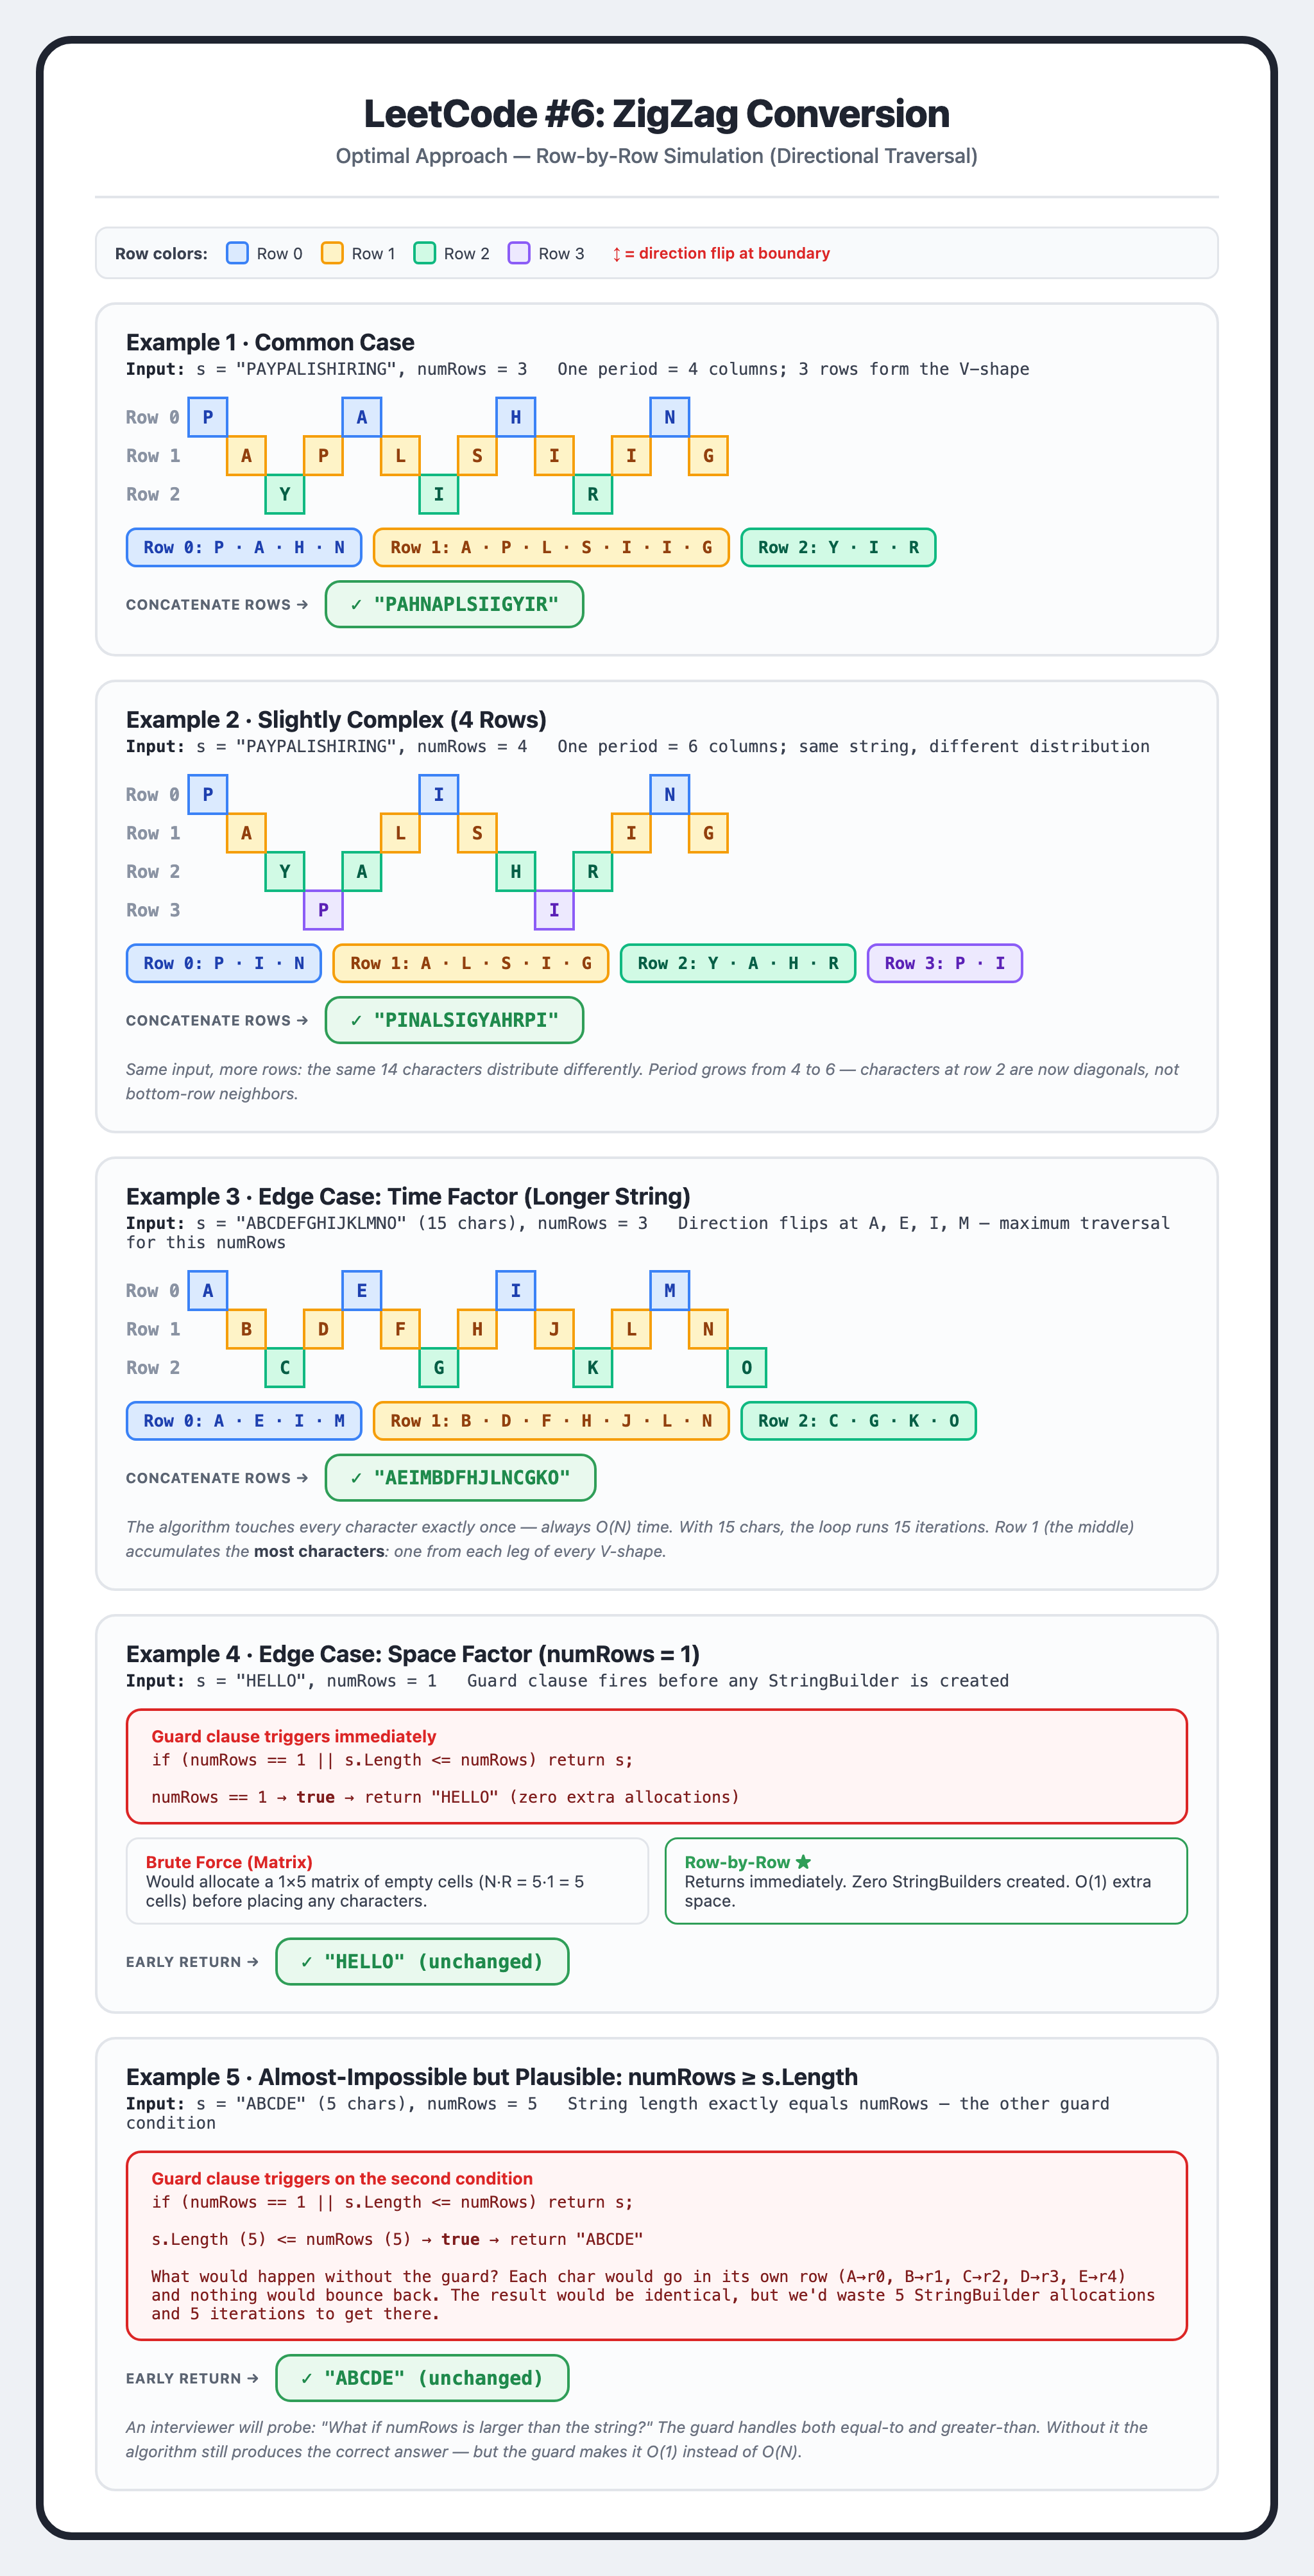